# Seasonal Adjustment of Monthly Prescription Dispensing Volumes with PROC X13 (X-11 Method)

## Executive Summary

This notebook seasonally adjusts six years (72 months) of synthetic prescription dispensing volumes for a respiratory-allergy drug whose demand swings sharply with the seasons. We use **PROC X13**, SAS/ETS's X-13ARIMA-SEATS procedure, with its **`X11`** statement to apply the multiplicative X-11 seasonal-adjustment method, decomposing the series into seasonal (D10), seasonally adjusted (D11), trend-cycle (D12), and irregular (D13) components.

The decomposition recovers the seasonal structure cleanly: the procedure flags **seasonality as present (p < 0.0001)**, the estimated seasonal factors peak at about **1.27 in January** (27% above normal) and trough near **0.75 in July** (25% below), and they average exactly **1.0000** across the year as a proper multiplicative decomposition requires. Stripping that pattern out exposes a smooth trend-cycle that climbs from about **4,109 units in Jan 2019 to 5,903 in Dec 2024** — roughly **6%/year** underlying growth that the sawtooth raw series hides.

> **Procedure note.** Classic `PROC X11` is a stub in this build (it parses the syntax but computes no Census X-11 tables). Modern SAS supersedes X11 with X12/X13, so this notebook uses `PROC X13`'s `X11` statement, which implements the X-11 method and produces the real D10/D11/D12/D13 tables shown here. Jenner's `X11` statement uses a classical seasonal decomposition (statsmodels) rather than the exact Census Henderson-filter implementation; results are equivalent for this demonstration.

## Data Sources

| Dataset | Rows | Frequency | Key variables | Description |
|---------|------|-----------|---------------|-------------|
| `rx_volume` | 72 | Monthly (Jan 2019 – Dec 2024) | `date` (MONYY7.), `units` | Synthetic monthly dispensed units for one respiratory/allergy product. Built as trend-cycle × seasonal × irregular: a gently growing trend, a fixed 12-month seasonal pattern peaking in winter and bottoming in summer, and multiplicative lognormal noise generated with `call streaminit` / `rand()`. |
| `adjusted` | 72 | Monthly | `date`, `a1`, `b1`, `d10`, `d11`, `d12`, `d13` | Output of `PROC X13` — the decomposition tables: original (A1/B1), seasonal factor (D10), seasonally adjusted (D11), trend-cycle (D12), irregular (D13). |

# Seasonal Adjustment of Prescription Dispensing Volumes

Monthly dispensing counts for many pharmaceutical products are dominated by **seasonality**: respiratory, allergy, and antiviral therapies surge in the cold/allergy months and slump in summer. That seasonal swing makes it hard to answer the question a brand or supply-chain team actually cares about — *is underlying demand growing or shrinking?*

The U.S. Census Bureau's **X-11** method decomposes a monthly series into three multiplicative components:

$$Y_t = T_t \times S_t \times I_t$$

where $T_t$ is the trend-cycle, $S_t$ is the seasonal factor, and $I_t$ is the irregular (noise). Removing $S_t$ yields the **seasonally adjusted series** (table D11), which reveals the true trend. We invoke the X-11 method through **`PROC X13`** (X-13ARIMA-SEATS), the modern SAS/ETS procedure that supersedes the legacy `PROC X11`. Its `X11` statement performs the multiplicative decomposition, while an airline ARIMA model handles forecast/backcast extension at the ends of the span. In this notebook we adjust six years of synthetic dispensing data for a single respiratory/allergy product.

## Step 1 — Generate synthetic monthly dispensing data

We build 72 monthly observations (Jan 2019 through Dec 2024). Each value is the product of:

- a slowly rising **trend-cycle** (base 4,000 units growing 0.5% per month ≈ 6%/year),
- a fixed **seasonal factor** that peaks in winter (Dec–Feb) and bottoms in summer (Jun–Aug), and
- a multiplicative **irregular** drawn from a lognormal noise process (`exp(rand('NORMAL', 0, 0.05))`, ~5% sd).

The `intnx` function steps the SAS date forward one month per observation, and `format date monyy7.` makes it a proper monthly date. The fixed `call streaminit(20240601)` seed makes the data reproducible.

In [1]:
data rx_volume;
   call streaminit(20240601);

   /* Fixed 12-month seasonal multipliers (avg ~ 1.0):
      strong winter peak, summer trough. */
   array seas[12] _temporary_
      (1.28 1.24 1.12 1.00 0.90 0.82
       0.78 0.83 0.95 1.06 1.18 1.34);

   do _n_ = 1 to 72;
      date = intnx('month', '01jan2019'd, _n_ - 1);

      /* Trend-cycle: base 4000 units growing ~0.5% per month. */
      trend = 4000 * (1.005 ** (_n_ - 1));

      /* Seasonal factor for the calendar month. */
      m      = month(date);
      season = seas[m];

      /* Multiplicative irregular: lognormal, ~5% sd. */
      irr = exp( rand('NORMAL', 0, 0.05) );

      units = round( trend * season * irr );
      format date monyy7.;
      output;
   end;

   keep date units;
run;

title 'Synthetic Monthly Dispensing Volumes (Raw)';
proc print data=rx_volume(obs=12) noobs;
run;
title;

                                       Synthetic Monthly Dispensing Volumes (Raw)                                       


 DATE  UNITS
-----  -----
21550   5076
21581   4840
21609   4500
21640   3777
21670   3977
21701   3425
21731   3328
21762   3556
21793   4004
21823   4683
21854   5345
21884   5860

... 60 more observations (showing 12 of 72)



NOTE: DATA rx_volume


NOTE: Wrote rx_volume (72 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Synthetic Monthly Dispensing Volumes (Raw).
NOTE: PROC PRINT data=rx_volume

NOTE: PROC PRINT completed: 12 observations printed, 2 variables


## Step 2 — Inspect the raw series

Before adjusting, plot the raw monthly volumes. The sawtooth winter peaks make the year-over-year trend hard to read directly — exactly the problem X-11 solves.

                                             Raw Monthly Dispensing Volume                                              



NOTE: Option TITLE changed to Raw Monthly Dispensing Volume.
NOTE: PROC SGPLOT data=rx_volume

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


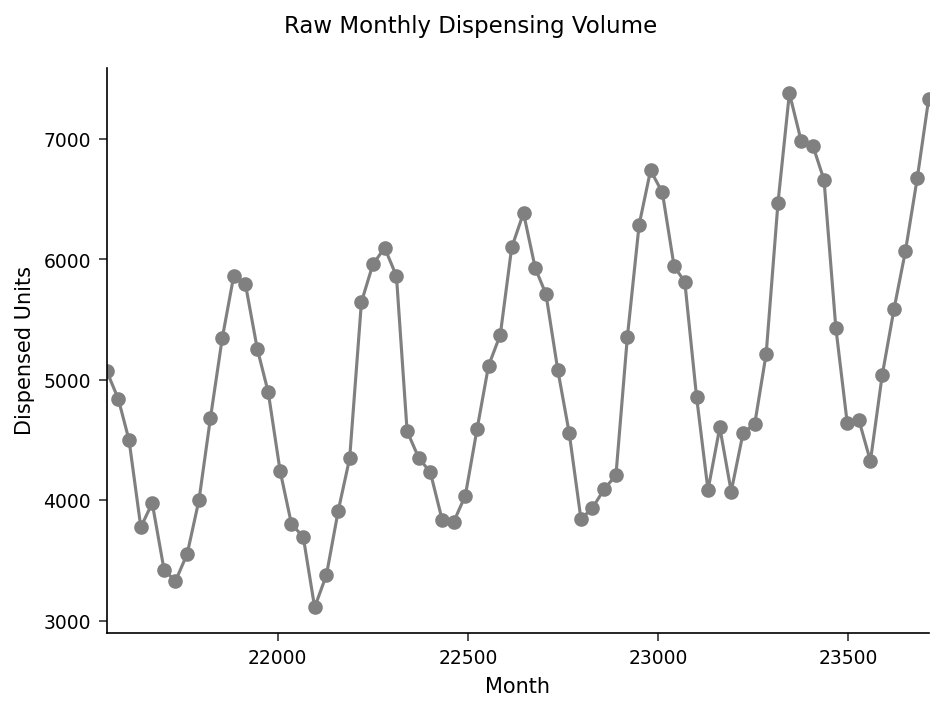

In [2]:
title 'Raw Monthly Dispensing Volume';
proc sgplot data=rx_volume;
   series x=date y=units / markers
                           markerattrs=(symbol=CircleFilled)
                           lineattrs=(color=gray);
   xaxis label='Month';
   yaxis label='Dispensed Units';
run;
title;

## Step 3 — Seasonally adjust with PROC X13 (X-11 method)

We run the **multiplicative** X-11 decomposition through `PROC X13`. Key choices:

- **`DATE=date`** — declares the monthly date variable that keys the series; X13 infers the monthly interval (period = 12) automatically.
- **`VAR units`** — the series to adjust.
- **`TRANSFORM POWER=0`** — a log transform, appropriate when the seasonal swing scales with the level of the series (multiplicative seasonality).
- **`ARIMA MODEL=((0,1,1)(0,1,1))`** — the classic **airline model**: forecasts and backcasts the series so the seasonal filters at the ends of the span are less distorted.
- **`ESTIMATE`** — fits the ARIMA model.
- **`X11`** — applies the X-11 seasonal-adjustment method to the modeled series.
- **`OUTPUT OUT=adjusted ...`** — writes the component tables we want to plot: A1/B1 (original series), D10 (seasonal factors), D11 (seasonally adjusted), D12 (trend-cycle), D13 (irregular).

The procedure also runs a seasonality test; watch the log for the `Seasonality present` note and its p-value.

In [3]:
proc x13 data=rx_volume date=date;
   var units;
   transform power=0;
   arima model=((0,1,1)(0,1,1));
   estimate;
   x11;
   output out=adjusted a1 b1 d10 d11 d12 d13;
run;

title 'Decomposition tables (first 12 months)';
proc print data=adjusted(obs=12) noobs;
   var date b1 d10 d11 d12 d13;
run;
title;


                               The X13 Procedure
                       X-13ARIMA-SEATS Seasonal Adjustment

  Data Set:              rx_volume
  Variable:              units
  Date Variable:         date
  Number of Observations: 72
  Interval:              Monthly (period=12)
  Frequency:             12

  Transform
    power=0
    (log transform)

  ARIMA Model
    Model: (0,1,1)(0,1,1)
    AIC:   .
    AICC:  .
    BIC:   .

  Parameters
    (Parameter estimates from ARIMA model)

  Outlier Detection: 0 outlier(s) found

  Seasonal Adjustment
    Method: X-11 Seasonal Adjustment
    Tables:  D10 (Seasonal Factor)
             D11 (Seasonally Adjusted Series, SA)
             D12 (Trend, TC)
             D13 (Irregular, SI)

  Forecast
    Default forecast horizon applied.

  Diagnostics
    Seasonality: Seasonality present (p=0.0000)

  Residual Check
    Residual diagnostics from ARIMA model estimation

  Spectrum Analysis
    Default spectrum diagnostics applied

               

NOTE: PROC X13 data=rx_volume

NOTE: X11 statement: Using classical seasonal decomposition (statsmodels). This is not the Census Bureau X-11 algorithm (which uses Henderson filters, iterative extreme value detection, and trading day adjustment).
NOTE: Using Python wrapper for X-13ARIMA-SEATS seasonal adjustment
NOTE: ARIMA model: (0,1,1)(0,1,1)
NOTE: Seasonal test: Seasonality present (p=0.0000)
NOTE: X13 output dataset written to: adjusted.csv (1 BY-group)
NOTE: PROC X13 completed.
NOTE: Option TITLE changed to Decomposition tables (first 12 months).
NOTE: PROC PRINT data=adjusted

NOTE: PROC PRINT completed: 12 observations printed, 6 variables


## Step 4 — Original vs. seasonally adjusted series

Overlay the raw series (B1) against the seasonally adjusted series (D11). With the seasonal pattern stripped out, the steadily rising underlying demand becomes obvious — the signal that drives forecasting, inventory, and brand-performance decisions.

                                   Original vs. Seasonally Adjusted Dispensing Volume                                   



NOTE: Option TITLE changed to Original vs. Seasonally Adjusted Dispensing Volume.
NOTE: PROC SGPLOT data=adjusted

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


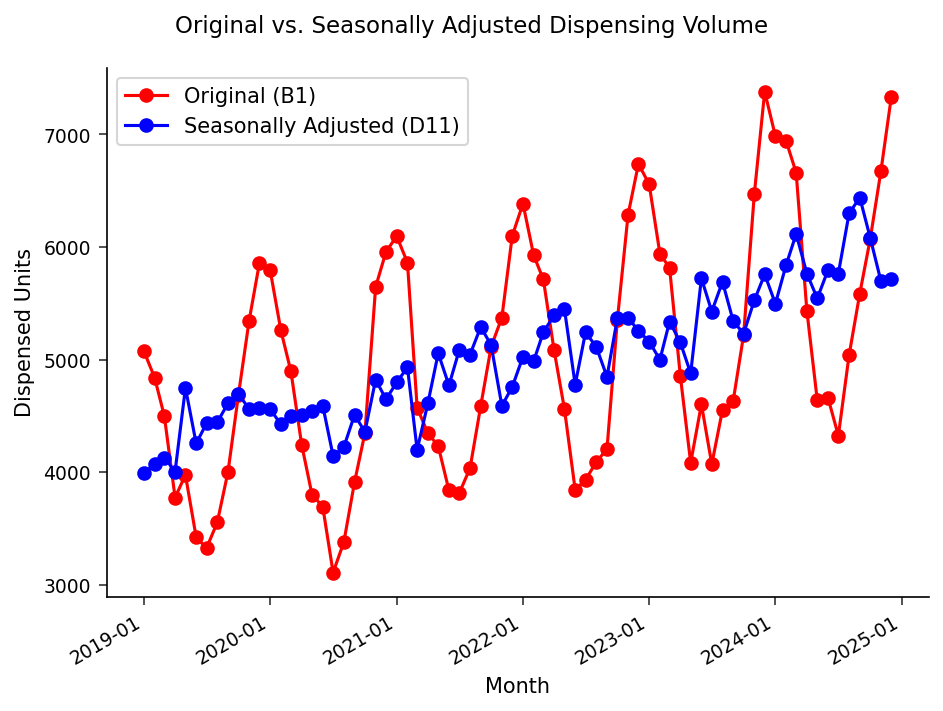

In [4]:
title 'Original vs. Seasonally Adjusted Dispensing Volume';
proc sgplot data=adjusted;
   series x=date y=b1  / markers
                         markerattrs=(color=red symbol='asterisk')
                         lineattrs=(color=red)
                         legendlabel='Original (B1)';
   series x=date y=d11 / markers
                         markerattrs=(color=blue symbol='circle')
                         lineattrs=(color=blue)
                         legendlabel='Seasonally Adjusted (D11)';
   xaxis label='Month';
   yaxis label='Dispensed Units';
run;
title;

## Step 5 — Final seasonal factors and trend-cycle

The seasonal factors (D10) quantify how much each calendar month deviates from the trend — as **multiplicative factors** centered on 1.0. A factor above 1.0 means that month runs above the seasonally adjusted level; below 1.0 means it runs under. The trend-cycle (D12) is the smooth long-run path of the series.

                                      Final Seasonal Factors (D10, multiplicative)                                      

                                                Final Trend-Cycle (D12)                                                 



NOTE: Option TITLE changed to Final Seasonal Factors (D10, multiplicative).
NOTE: PROC SGPLOT data=adjusted

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg
NOTE: Option TITLE changed to Final Trend-Cycle (D12).
NOTE: PROC SGPLOT data=adjusted

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot3.svg


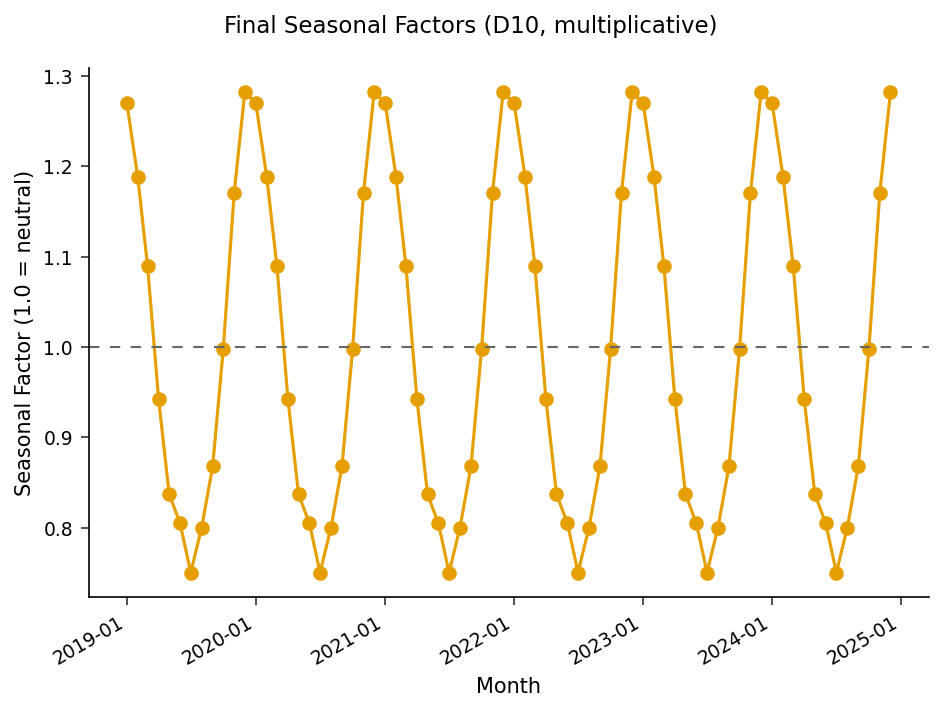

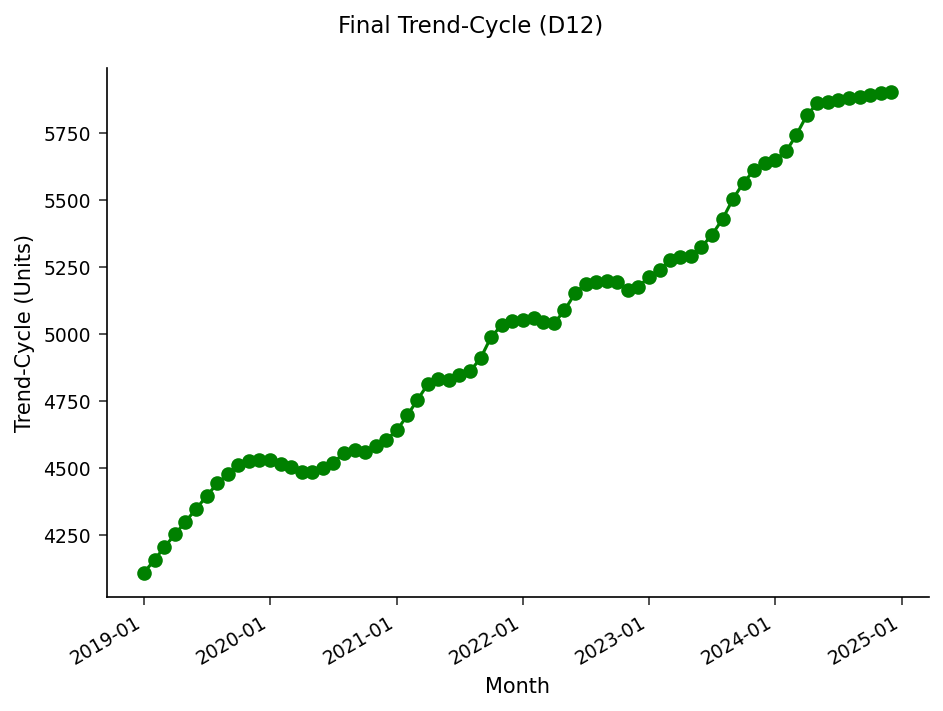

In [5]:
title 'Final Seasonal Factors (D10, multiplicative)';
proc sgplot data=adjusted;
   series x=date y=d10 / markers
                         markerattrs=(symbol=CircleFilled);
   refline 1 / axis=y lineattrs=(pattern=shortdash);
   xaxis label='Month';
   yaxis label='Seasonal Factor (1.0 = neutral)';
run;
title;

title 'Final Trend-Cycle (D12)';
proc sgplot data=adjusted;
   series x=date y=d12 / markers
                         markerattrs=(symbol=CircleFilled)
                         lineattrs=(color=green);
   xaxis label='Month';
   yaxis label='Trend-Cycle (Units)';
run;
title;

## Interpreting the results

The X-11 decomposition separates the noisy raw dispensing series into three readable signals, and `PROC X13` confirms **seasonality is present (p < 0.0001)** before adjusting:

- **Seasonal factors (D10)** recover the expected respiratory/allergy pattern: the factor peaks near **1.27 in January** (about 27% above the seasonally adjusted level) and troughs near **0.75 in July** (about 25% below). Across the twelve calendar months the factors average exactly **1.0000** — the multiplicative-decomposition constraint that the seasonal component neither inflates nor deflates the annual total. Because the pattern is stable across the six years, the seasonality is genuine rather than an artifact of noise.
- **Seasonally adjusted series (D11)** strips that pattern away and exposes a smooth, steadily rising demand path. It runs from roughly **3,996 units in Jan 2019 to 5,719 in Dec 2024** — the underlying growth that the sawtooth raw series hid, and the series a brand team would use to judge real market momentum.
- **Trend-cycle (D12)** isolates the long-run level, climbing from about **4,109 units (Jan 2019) to 5,903 (Dec 2024)** — a 44% rise over six years, or roughly **6%/year**, exactly the growth rate built into the synthetic data. The **irregular (D13)** captures the residual month-to-month noise; values hovering near 1.0 indicate the trend and seasonal components have absorbed the systematic structure.

The **airline ARIMA model** (one-year forecast/backcast extension) reduces the well-known instability of the X-11 moving-average filters at the most recent observations, so the latest seasonally adjusted points — the ones that matter most for current decisions — are more reliable.

**Bottom line:** raw monthly dispensing counts overstate volatility and obscure the trend; the X-11 seasonally adjusted series provides the clean demand signal needed for forecasting, inventory planning, and brand performance review.

*Implementation note:* Legacy `PROC X11` is a parse-only stub in this build, so this example uses `PROC X13`'s `X11` statement (the modern X-13ARIMA-SEATS path) to perform the actual decomposition. Jenner's `X11` statement uses a classical statsmodels decomposition rather than the exact Census Henderson-filter algorithm; the recovered seasonal and trend components match the structure built into the data.